# Out Probability Model

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

## modeling libraries
import pymc as pm 
import pymc_bart as pmb 
import arviz as az 

from sklearn.metrics import brier_score_loss, log_loss, roc_auc_score
from sklearn.calibration import calibration_curve
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

import xgboost as xgb

red_color = '#ba0c2f'

In [30]:
batted_balls = pd.read_parquet('data/ball_event_data.parquet')
batted_balls['BatSide'] = batted_balls['BatSide'].apply(lambda x: 1 if x=='R' else 0)
batted_balls['BallInPlayType'] = batted_balls['BallInPlayType'].apply(lambda x: 1 if x=='Grounder' else 0)
batted_balls['Season'] = batted_balls['Season'].apply(lambda x: 1 if x==2023 else 0)

In [31]:
feats = batted_balls.iloc[:, 1:].columns.to_list()
target = 'ActualOut'

X_train, X_test, y_train, y_test = train_test_split(batted_balls[feats], batted_balls[target], stratify=batted_balls[target], test_size=0.2, random_state=42)

In [33]:
with pm.Model() as spatial_infield_model:
    ## data containers (these are the training sets)
    X_data = pm.Data("X", X_train)
    y_data = pm.Data("y", y_train)
    
    ## the BART prior --> we use 50 trees to allow for smoother spatial contours
    mu_bart = pmb.BART("mu_bart", X=X_data, Y=y_data, m=50)
    
    ## we model originally in the log odds --> we translate them into the [0, 1] space for probs
    p_out = pm.Deterministic("p_out", pm.math.invlogit(mu_bart))

    ## bernoulli likelihood since each observation is binary
    obs = pm.Bernoulli("obs", p=p_out, observed=y_data)

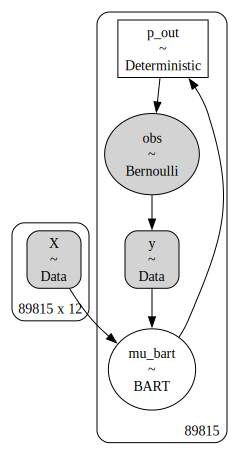

In [34]:
pm.model_to_graphviz(spatial_infield_model)

In [35]:
with spatial_infield_model:
    idata = pm.sample(tune = 1000, draws = 1000, chains = 4, cores = 4, random_seed = 42)

Multiprocess sampling (4 chains in 4 jobs)
PGBART: [mu_bart]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3667 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [36]:
az.summary(idata)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_bart[0],-3.300,0.645,-4.616,-2.115,0.027,0.016,565.0,1079.0,1.01
mu_bart[1],2.466,0.304,1.862,2.977,0.014,0.008,447.0,681.0,1.00
mu_bart[2],1.277,0.359,0.576,1.939,0.015,0.009,551.0,862.0,1.00
mu_bart[3],1.933,0.274,1.427,2.478,0.010,0.007,684.0,1060.0,1.01
mu_bart[4],2.286,0.301,1.747,2.852,0.012,0.005,686.0,1224.0,1.00
...,...,...,...,...,...,...,...,...,...
p_out[89810],0.028,0.019,0.005,0.062,0.001,0.001,595.0,1118.0,1.00
p_out[89811],0.561,0.097,0.371,0.725,0.004,0.002,587.0,1039.0,1.00
p_out[89812],0.910,0.026,0.860,0.953,0.001,0.001,493.0,1334.0,1.00
p_out[89813],0.448,0.116,0.233,0.662,0.005,0.003,544.0,829.0,1.00


In [ ]:
with spatial_infield_model:
    pm.set_data({"X": X_test, "y": y_test})
    post_pred = pm.sample_posterior_predictive(idata, random_seed=42)
predicted_probabilities = post_pred.posterior_predictive["obs"].mean(dim=("chain", "draw")).values

Sampling: [mu_bart, obs]


Output()

In [44]:
def plot_bart_calibration(y_test, posterior_probs, n_bins=10, n_draws_to_plot=100, blue_color='#1f77b4', red_color='#d62728'):
    """
    Plots a Bayesian calibration curve with uncertainty bands and a prediction histogram
    specifically tailored for the PyMC-BART out-probability model.
    """
    y_true_np = np.array(y_test)    
    mean_probs = posterior_probs.mean(axis=0)

    fig, ax1 = plt.subplots()    
    total_draws = posterior_probs.shape[0]
    n_draws_to_plot = min(n_draws_to_plot, total_draws)
    draw_indices = np.random.choice(total_draws, size=n_draws_to_plot, replace=False)
    
    for idx in draw_indices:
        sample_probs = posterior_probs[idx]        
        emp_pct, pred_pct = calibration_curve(y_true_np, sample_probs, n_bins=n_bins, strategy='uniform')
        ax1.plot(pred_pct, emp_pct, color=blue_color, alpha=0.03)

    emp_mean, pred_mean = calibration_curve(y_true_np, mean_probs, n_bins=n_bins, strategy='uniform')
    ax1.plot(pred_mean, emp_mean, marker='o', linewidth=2, color=blue_color, label='Posterior Mean')
    ax1.plot([0, 1], [0, 1], linestyle='--', color=red_color, label='Perfect Calibration')    
    ax1.set_xlim([-0.05, 1.05])
    ax1.set_ylim([-0.05, 1.05])
    ax1.set_xlabel('Predicted Probability of Out')
    ax1.set_ylabel('Empirical Probability of Out')
    ax1.set_title('BART Predicted vs. Empirical Out%')
    ax1.legend(loc="upper left")
    ax1.grid(True, alpha=0.3)
    ax2 = ax1.twinx()
    ax2.hist(mean_probs, bins=50, alpha=0.2, color='gray', density=False)
    ax2.set_ylabel('Count of Batted Balls', color='gray')
    ax2.tick_params(axis='y', labelcolor='gray')    
    counts, _ = np.histogram(mean_probs, bins=50)
    ax2.set_ylim([0, max(counts) * 3]) 
    plt.show()

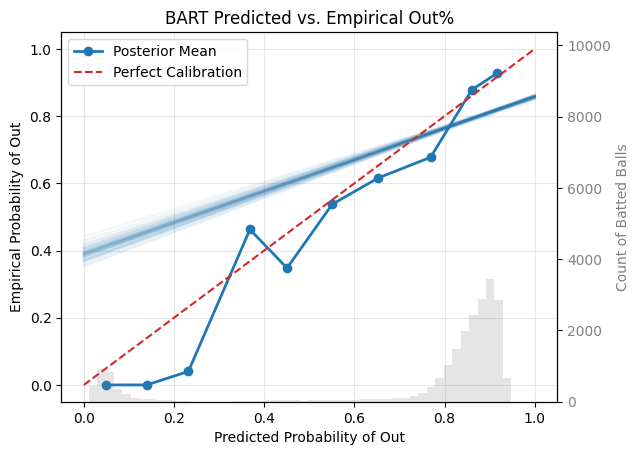

In [45]:
stacked_probs = post_pred.posterior_predictive["obs"].stack(sample=("chain", "draw"))
posterior_probs_2d = stacked_probs.values.T
plot_bart_calibration(y_test=y_test, posterior_probs=posterior_probs_2d)

In [ ]:
## empirical out% baseline
out_rate_train = y_train.mean() 
probs_emp = np.full(len(y_test), out_rate_train)

## random coin flip baseline
probs_random = np.random.uniform(0, 1, size=len(y_test))

## logistic regression baseline
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
probs_lr = lr_model.predict_proba(X_test)[:, 1]

## xgboost baseline
xgb = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, eval_metric='logloss')
xgb.fit(X_train, y_train)
probs_xgb = xgb.predict_proba(X_test)[:, 1]

## generates the comparison table
models = {"Empirical Rate": probs_emp, 
          "Random Flip": probs_random,
          "Logit": probs_lr,
          "XGBoost": probs_xgb,
          "PyMC-BART": predicted_probabilities 
          }
stats = []
for name, probs in models.items():
    stats.append({"Model": name, 
                  "Brier Score": brier_score_loss(y_test, probs), 
                  "Log-Loss": log_loss(y_test, probs), 
                  "ROC-AUC": roc_auc_score(y_test, probs)
                  })
comparison_df = pd.DataFrame(stats)
comparison_df

         Model  Brier Score  Log-Loss  ROC-AUC
       XGBoost     0.080990  0.277189 0.902589
     PyMC-BART     0.096523  0.330522 0.863653
         Logit     0.113394  0.399147 0.797641
   Random Flip     0.330638  0.993411 0.503919
Empirical Rate     0.193696  0.575877 0.500000


## Vulnerable Zone Analysis + Added Shift Value

In [127]:
all_data_context = pd.read_parquet('data/all_data_context.parquet')
id_columns = ['Pos', 'pitcher', 'fielder_2', 'fielder_3', 'fielder_4', 'fielder_5', 'fielder_6']
id_cols_safe = [col for col in id_columns if col in all_data_context.columns]

## the ids join batted balls on the index
df_full = batted_balls.join(all_data_context[id_cols_safe])
df_full['BatSide'] = df_full['BatSide'].apply(lambda x: 1 if x=='R' else 0)
df_full['BallInPlayType'] = df_full['BallInPlayType'].apply(lambda x: 1 if x=='Grounder' else 0)
df_full['Season'] = df_full['Season'].apply(lambda x: 1 if x==2023 else 0)

## isolates all of the 2023 data
df_2023 = df_full[df_full['Season'] == 1].reset_index(drop=True).copy()

## the 2022 data is the counterfactual for all of the 2023 plays
df_2022 = df_2023.copy()
df_2022['Season'] = 0

## creates predictions on the full 2023 set and the counterfactual "2022" set
with spatial_infield_model:
    ## 2023
    pm.set_data({"X": df_2023[feats], "y": df_2023['ActualOut']})
    post_pred_2023 = pm.sample_posterior_predictive(idata, random_seed=42)
    p_2023_actual = post_pred_2023.posterior_predictive["obs"].mean(dim=("chain", "draw")).values
    
    ## "2022"
    pm.set_data({"X": df_2022[feats], "y": df_2023['ActualOut']})
    post_pred_2022 = pm.sample_posterior_predictive(idata, random_seed=42)
    p_2022 = post_pred_2022.posterior_predictive["obs"].mean(dim=("chain", "draw")).values

Sampling: [mu_bart, obs]


Output()

Sampling: [mu_bart, obs]


Output()

In [129]:
df_results = df_2023.copy()
df_results['p_2023'] = p_2023_actual
df_results['p_2022'] = p_2022

## calculates the change in out probability and finds OAA (based on 2023)
df_results['delta'] = np.maximum(0, df_results['p_2022'] - df_results['p_2023'])
df_results['OAA'] = df_results['ActualOut'] - df_results['p_2023']

## our metric ASV: if they make the out, it adds delta
df_results['ASV'] = np.where(df_results['ActualOut'] == 1, 
                             df_results['OAA'] + df_results['delta'], 
                             df_results['OAA'])

## extracts the fielder ID based on the column "pos"
df_results['pos_clean'] = df_results['Pos'].astype(str).str.replace('.0', '', regex=False).str.strip().str.upper()

pos_conds = [df_results['pos_clean'].isin(['1', 'P']), 
              df_results['pos_clean'].isin(['2', 'C']),
              df_results['pos_clean'].isin(['3', '1B']),
              df_results['pos_clean'].isin(['4', '2B']),
              df_results['pos_clean'].isin(['5', '3B']),
              df_results['pos_clean'].isin(['6', 'SS'])
              ]
statcast_id_cols = [df_results['pitcher'],
           df_results['fielder_2'],
           df_results['fielder_3'], 
           df_results['fielder_4'],
           df_results['fielder_5'],
           df_results['fielder_6']
           ]

df_results['fielderid'] = np.select(pos_conds, statcast_id_cols, default=np.nan)
df_infield_results = df_results.dropna(subset=['fielderid'])

leaderboard = (df_infield_results
               .groupby('fielderid')
               .agg(plays=('ActualOut', 'count'), total_OAA=('OAA', 'sum'), total_ASV=('ASV', 'sum'))
               .reset_index()
               )
leaderboard['outs_added'] = leaderboard['total_ASV'] - leaderboard['total_OAA']
leaderboard = leaderboard.sort_values(by='outs_added', ascending=False)
leaderboard

,fielderid,plays,total_OAA,total_ASV,outs_added
324,621020.0,503,1.81675,2.03700,0.22025
1033,682928.0,509,-5.02325,-4.80300,0.22025
499,646240.0,472,-6.54675,-6.33000,0.21675
125,553993.0,515,0.33725,0.55375,0.21650
1038,683011.0,490,-10.98550,-10.77025,0.21525
...,...,...,...,...,...
924,676083.0,1,0.09250,0.09250,0.00000
925,676092.0,4,0.15550,0.15550,0.00000
753,666310.0,5,-0.38075,-0.38075,0.00000
347,621512.0,2,-1.66175,-1.66175,0.00000


In [132]:
leaderboard['fielderid'] = leaderboard['fielderid'].astype(int) 

## we set a qualification min of 200 plays --> we don't want to see low number of chances
qualifier = 100
qualified_board = leaderboard[leaderboard['plays'] >= qualifier].reset_index(drop=True).copy()

## we decided to normalize ASV over 100 chances to account for differences in ASV as a result of sample size
qualified_board['ASV/100'] = (qualified_board['outs_added'] / qualified_board['plays']) * 100

## calculates the mean and sd of the rate
mean_rate = qualified_board['ASV/100'].mean()
std_rate = qualified_board['ASV/100'].std()

## ASV/100 isn't that interpretable --> make it a plus stat where mu = 100, sigma = 10
qualified_board['ASV+'] = 100 + ((qualified_board['ASV/100'] - mean_rate) / std_rate) * 10
qualified_board['ASV+'] = qualified_board['ASV+'].round(1) ## makes it an int

## a leaderboard of our metric
presentation_board = qualified_board[['fielderid', 'plays', 'total_OAA', 'outs_added', 'ASV/100', 'ASV+']].copy()
presentation_board = presentation_board.sort_values(by='ASV+', ascending=False)
presentation_board

,fielderid,plays,total_OAA,outs_added,ASV/100,ASV+
152,643396,103,1.46925,0.05350,0.051942,129.7
127,622569,132,4.05175,0.06700,0.050758,126.6
149,647304,111,-0.82325,0.05500,0.049550,123.4
97,680911,164,0.89775,0.08125,0.049543,123.4
134,663898,128,3.26700,0.06325,0.049414,123.1
...,...,...,...,...,...,...
162,456781,145,1.13925,0.04875,0.033621,81.6
157,669701,150,-2.61325,0.04975,0.033167,80.4
177,621545,107,-4.83675,0.03550,0.033178,80.4
120,545121,211,-0.90975,0.06925,0.032820,79.5


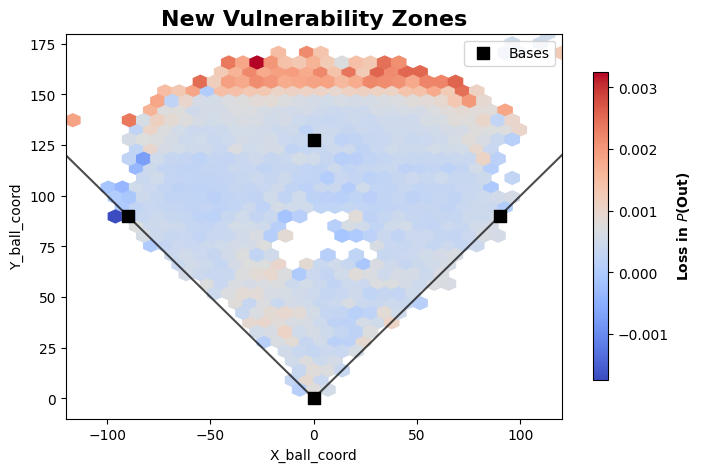

In [ ]:
# the visual of where the new vulnerable zone

df_results['prob_diff'] = df_results['p_2022'] - df_results['p_2023']

## we want to keep it only to the infield, where we're focusing
infield_zoom = df_results[df_results['Y_ball_coord'] < 180].copy()

## some field dims
lf_x_values = np.linspace(0, -200)
lf_foul_line = -lf_x_values
rf_x_values = np.linspace(0, 200)
rf_foul_line = rf_x_values
bases_x = [90, 0, 0, -90]
bases_y = [90, 0, np.sqrt(90**2 + 90**2), 90]

## the plot
plt.figure(figsize=(8, 5), facecolor='white')
ax = plt.gca()
hb = ax.hexbin(infield_zoom['X_ball_coord'], 
               infield_zoom['Y_ball_coord'], 
               C=infield_zoom['prob_diff'], 
               gridsize=35, 
               cmap='coolwarm', 
               reduce_C_function=np.mean, 
               mincnt=2, 
               extent=[-120, 120, -10, 180]
               )
ax.plot(lf_x_values, lf_foul_line, c="k", lw=1.5, alpha=0.7)
ax.plot(rf_x_values, rf_foul_line, c="k", lw=1.5, alpha=0.7)
ax.scatter(bases_x, bases_y, color="k", marker="s", s=80, label="Bases", zorder=5)
cb = plt.colorbar(hb, ax=ax, shrink=0.8)
cb.set_label(r'Loss in $P$(Out)', fontweight='bold')
ax.set_xlim(-120, 120)
ax.set_ylim(-10, 180)
ax.set_title("New Vulnerability Zones", fontsize=16, fontweight='bold')
ax.set_xlabel("X_ball_coord")
ax.set_ylabel("Y_ball_coord")
ax.legend()
plt.show()